In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib tk

In [3]:
energy_df = pd.read_excel('data/Dataset.xlsx', sheet_name='2023 data', usecols='A:F', nrows=8762)
energy_df.tail()

,Date,PV generation (kW),Consumption (kW),Consumption (pu),Energy price (EUR/MWh),Energy price (EUR/kWh)
8755,2023-12-31 19:00:00,0,2038,0.171751,101.30,0.10130
8756,2023-12-31 20:00:00,0,2013,0.169644,92.97,0.09297
8757,2023-12-31 21:00:00,0,2026,0.170740,85.49,0.08549
8758,2023-12-31 22:00:00,0,2027,0.170824,74.74,0.07474
8759,2023-12-31 23:00:00,0,2027,0.170824,71.96,0.07196


In [4]:
energy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    8760 non-null   datetime64[us]
 1   PV generation (kW)      8760 non-null   int64         
 2   Consumption (kW)        8760 non-null   int64         
 3   Consumption (pu)        8760 non-null   float64       
 4   Energy price (EUR/MWh)  8760 non-null   float64       
 5   Energy price (EUR/kWh)  8760 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(2)
memory usage: 410.8 KB


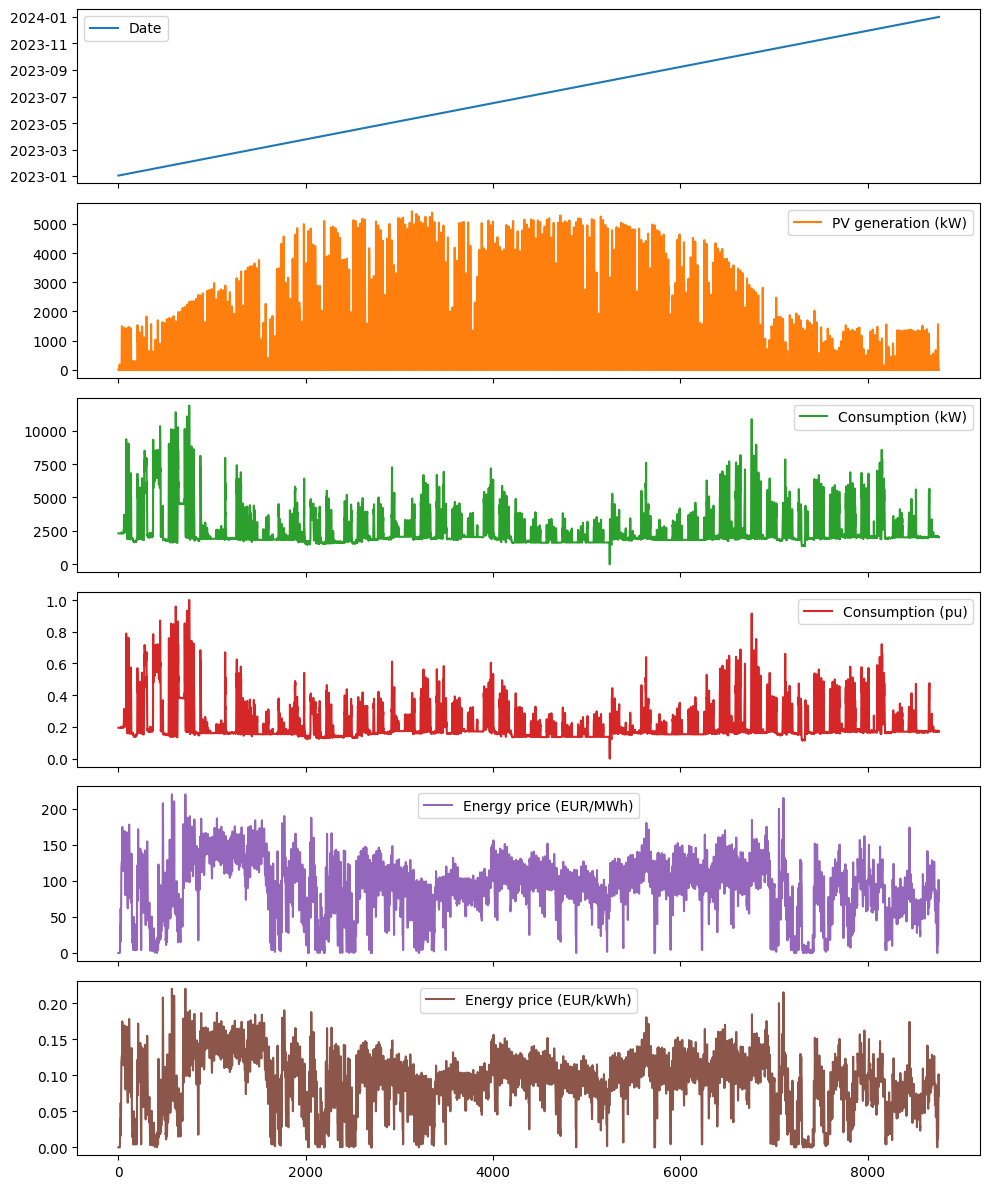

In [5]:
# plot all the columns
energy_df.plot(subplots=True, figsize=(10, 12))
plt.tight_layout()

In [6]:
# Seasonal data
seaons = ['Winter', 'Spring', 'Summer', 'Autumn']
season_dict = {seas: pd.read_excel('data/Dataset.xlsx', sheet_name=seas) for seas in seaons}

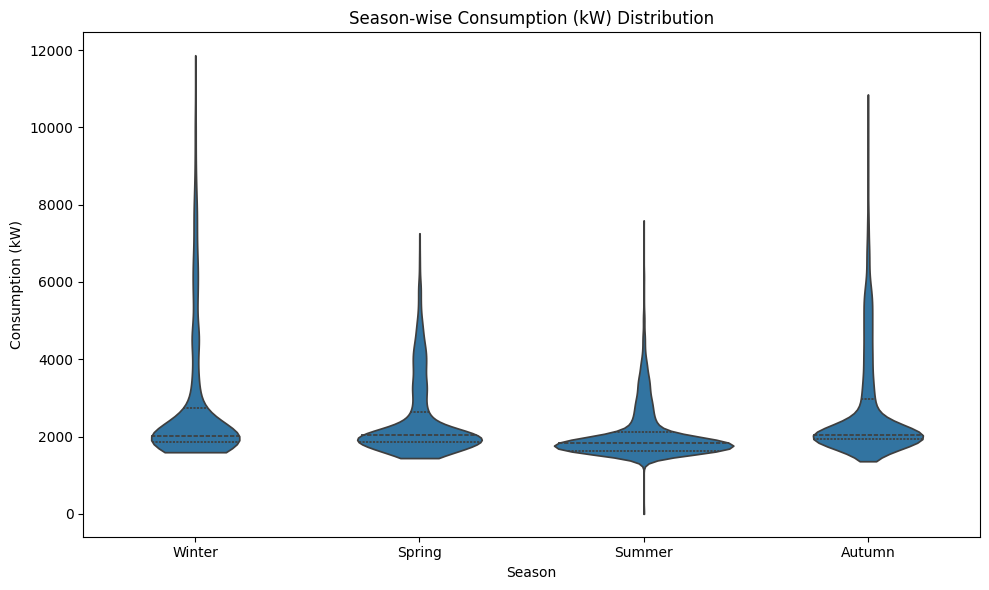

In [7]:
# Season-wise consumption data

# build long-form data for violin plot
consumption_long = pd.concat(
    [
        season_dict[seas][['Consumption (kW)']].assign(Season=seas)
        for seas in seaons
    ],
    ignore_index=True
 )

# violin plot of consumption by season
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=consumption_long,
    x='Season',
    y='Consumption (kW)',
    inner='quartile',
    cut=0
 )
ax.set_title('Season-wise Consumption (kW) Distribution')
ax.set_xlabel('Season')
ax.set_ylabel('Consumption (kW)')
plt.tight_layout()

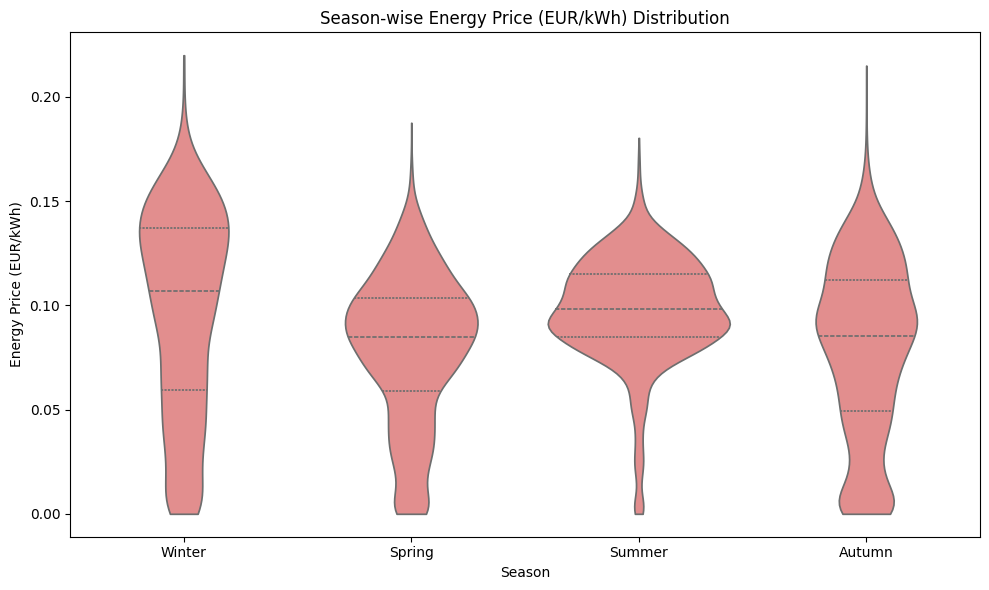

In [8]:
# Season-wise price data

# build long-form data for violin plot
price_long = pd.concat(
    [
        season_dict[seas][['Energy price (EUR/kWh)']].assign(Season=seas)
        for seas in seaons
    ],
    ignore_index=True
 )

# violin plot of consumption by season
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=price_long,
    x='Season',
    y='Energy price (EUR/kWh)',
    inner='quartile',
    cut=0,
    color='lightcoral'
 )
ax.set_title('Season-wise Energy Price (EUR/kWh) Distribution')
ax.set_xlabel('Season')
ax.set_ylabel('Energy Price (EUR/kWh)')
plt.tight_layout()

- The energy prices high variance in winter and autumn seasons compared to summer. Supply contraints and demand surge during winter and autumn seasons could be the reason for this high variance. In summer, the demand is relatively stable, leading to lower price volatility.

In [20]:
import json

with open("scripts/sample_BESS.json", "r") as f:
    battery_data = json.load(f)

battery_data

[{'id': 'battery_1',
  'capacity': 250.0,
  'max_charge': 65.0,
  'max_discharge': 65.0,
  'charge_efficiency': 0.95,
  'discharge_efficiency': 0.95,
  'initial_soc': 50.0,
  'min_soc': 15.0,
  'max_soc': 215.0},
 {'id': 'battery_2',
  'capacity': 300.0,
  'max_charge': 100.0,
  'max_discharge': 100.0,
  'charge_efficiency': 0.93,
  'discharge_efficiency': 0.93,
  'initial_soc': 75.0,
  'min_soc': 25.0,
  'max_soc': 250.0}]

In [21]:
from esms.models import Battery

Battery.from_dict(battery_data[0])

Battery(id='battery_1', capacity=250.0kWh, max_charge=65.0kW, max_discharge=65.0kW, η_rt=90.25%)

In [22]:
optim_df = pd.read_csv("day_ahead_optimization_results.csv")
optim_df.head()

,pv,load,price,export_price,grid_import,grid_export,battery_1_charge,battery_1_discharge,battery_1_soc,battery_2_charge,battery_2_discharge,battery_2_soc
0,0,2313,0.0,0.0,2283.5325,0.0,0.0,19.2375,29.75,0.0,10.23,64.0
1,0,2308,0.0,0.0,2308.0000,0.0,0.0,0.0000,29.75,0.0,0.00,64.0
2,0,2308,0.0,0.0,2308.0000,0.0,0.0,0.0000,29.75,0.0,0.00,64.0
3,0,2306,0.0,0.0,2306.0000,0.0,0.0,0.0000,29.75,0.0,0.00,64.0
4,0,2306,0.0,0.0,2306.0000,0.0,0.0,0.0000,29.75,0.0,0.00,64.0


In [23]:
plt.figure()
sns.lineplot(data=optim_df, y='load', x=np.arange(len(optim_df)), label='Load')
sns.lineplot(data=optim_df, y='pv', x=np.arange(len(optim_df)), label='PV Generation')
plt.title("Load and PV Generation Over Time")
plt.show()

In [24]:
plt.figure()
sns.lineplot(data=optim_df, y='grid_import', x=np.arange(len(optim_df)), label='Grid Import')
sns.lineplot(data=optim_df, y='grid_export', x=np.arange(len(optim_df)), label='Grid Export')
plt.title("Grid Import and Export Over Time")
plt.show()

In [ ]:
plt.figure()
sns.lineplot(data=optim_df, y='battery_2_soc', x=np.arange(len(optim_df)), label='Battery 2 SOC')
sns.lineplot(data=optim_df, y='battery_1_soc', x=np.arange(len(optim_df)), label='Battery 1 SOC')
plt.title("Battery State of Charge Over Time")
plt.show()

In [ ]:
plt.figure()
sns.lineplot(data=optim_df, y='battery_1_charge', x=np.arange(len(optim_df)), label='Battery 1 Charge', marker='o')
sns.lineplot(data=optim_df, y='battery_1_discharge', x=np.arange(len(optim_df)), label='Battery 1 Discharge', marker='x')
plt.title("Battery 1 Charge and Discharge Over Time")
plt.figure()

plt.show()